In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Outils de validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, recall_score, f1_score, precision_recall_curve

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Indispensable pour la Cross-Val propre

# Les Modèles demandés (Section 3.3 du PDF)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid")

# 1. Chargement
try:
    data = pd.read_csv("uci-secom.csv")
    print("Données chargées.")
except:
    print("Erreur : Fichier introuvable.")

# 2. Nettoyage Préliminaire
# On supprime les colonnes inutiles avant tout
cols_to_drop = [c for c in ['Time', 'Phase'] if c in data.columns]
data = data.drop(columns=cols_to_drop)

X = data.drop(columns=['Pass/Fail'])
y = data['Pass/Fail'].replace({-1: 0}) # 0=Bon, 1=Défaut

print(f"Dimensions X : {X.shape}")

Données chargées.
Dimensions X : (1567, 590)


Train set : (1096, 590)
Test set  : (471, 590)


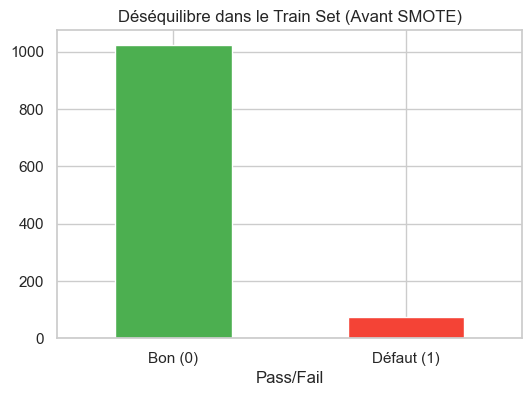

In [11]:
# SPLIT AVANT TOUT TRAITEMENT
# Train (70%) : Pour apprendre, nettoyer, et tuner.
# Test (30%) : Coffre-fort intouchable pour l'évaluation finale.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

# Visualisation du déséquilibre
plt.figure(figsize=(6, 4))
y_train.value_counts().plot.bar(color=['#4CAF50', '#F44336'])
plt.title("Déséquilibre dans le Train Set (Avant SMOTE)")
plt.xticks([0, 1], ['Bon (0)', 'Défaut (1)'], rotation=0)
plt.show()

In [12]:
# 1. Imputation (Remplacer les NaN)
imputer = SimpleImputer(strategy='median')
# On FIT sur le Train, on TRANSFORM le Train et le Test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Scaling (Mise à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 3. SMOTE (Sur le TRAIN uniquement !)
print("Application de SMOTE sur le Train set...")
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

print(f"Défauts Train AVANT SMOTE : {sum(y_train==1)}")
print(f"Défauts Train APRÈS SMOTE : {sum(y_train_final==1)}")
print(f"Défauts Test (Réalité)    : {sum(y_test==1)} (On n'y touche pas !)")

Application de SMOTE sur le Train set...
Défauts Train AVANT SMOTE : 73
Défauts Train APRÈS SMOTE : 1023
Défauts Test (Réalité)    : 31 (On n'y touche pas !)


MODÈLE               | AUC        | RECALL     | F1        
------------------------------------------------------------
Decision Tree        | 0.5788     | 0.2258     | 0.2059
Random Forest        | 0.8271     | 0.0000     | 0.0000
AdaBoost             | 0.7337     | 0.2581     | 0.2192
Neural Network       | 0.6625     | 0.1290     | 0.1633


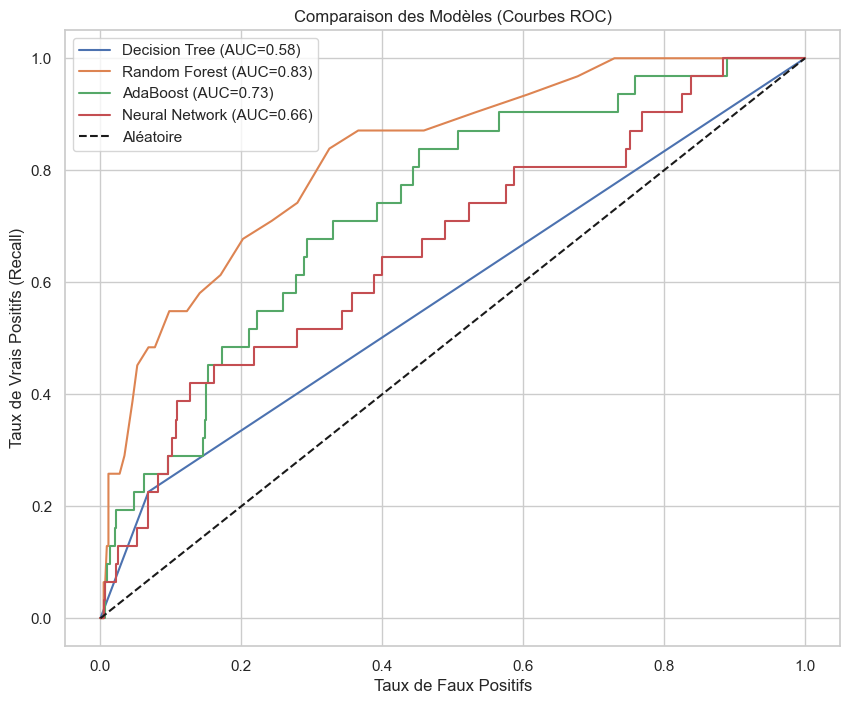

In [13]:
# Dictionnaire des modèles
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

plt.figure(figsize=(10, 8))
results_table = []

print(f"{'MODÈLE':<20} | {'AUC':<10} | {'RECALL':<10} | {'F1':<10}")
print("-" * 60)

for name, model in models.items():
    # Entraînement sur données équilibrées
    model.fit(X_train_final, y_train_final)
    
    # Prédiction sur Test Set (Scalé mais NON SMOTÉ)
    y_pred = model.predict(X_test_scaled)
    
    # Probabilités pour ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = y_pred
        
    # Métriques
    auc_val = roc_auc_score(y_test, y_prob)
    rec_val = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    
    results_table.append(name)
    print(f"{name:<20} | {auc_val:.4f}     | {rec_val:.4f}     | {f1_val:.4f}")
    
    # Plot ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.title('Comparaison des Modèles (Courbes ROC)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.legend()
plt.show()

In [14]:
print("--- VALIDATION CROISÉE (Robustesse) ---")
# On utilise un Pipeline spécial pour faire le SMOTE à l'intérieur de chaque pli de validation
# C'est la méthode la plus rigoureuse.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Pipeline : Impute -> Scale -> SMOTE -> Model
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    
    # On valide sur le X_train original (non traité) pour simuler tout le processus
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<20} : AUC Moyen = {scores.mean():.4f} (+/- {scores.std():.2f})")

--- VALIDATION CROISÉE (Robustesse) ---
Decision Tree        : AUC Moyen = 0.5361 (+/- 0.03)
Random Forest        : AUC Moyen = 0.6503 (+/- 0.07)
AdaBoost             : AUC Moyen = 0.6049 (+/- 0.04)
Neural Network       : AUC Moyen = 0.6288 (+/- 0.05)


--- OPTIMISATION DU SEUIL ---
Seuil optimal trouvé : 0.0000
Ce seuil garantit de détecter 87% des défauts.


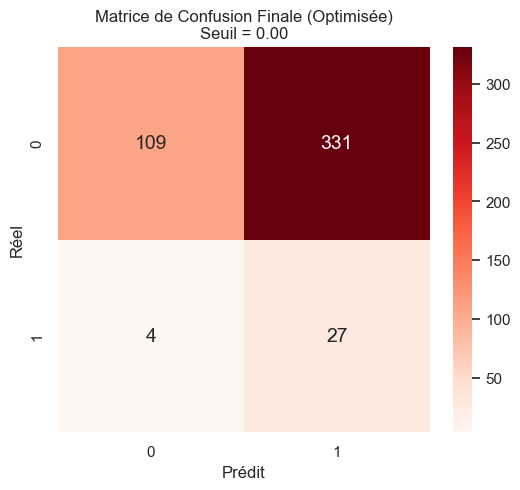

              precision    recall  f1-score   support

           0       0.96      0.25      0.39       440
           1       0.08      0.87      0.14        31

    accuracy                           0.29       471
   macro avg       0.52      0.56      0.27       471
weighted avg       0.91      0.29      0.38       471



In [15]:
# On reprend le Neural Network déjà entraîné
best_model = models['Neural Network']
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# On cherche le seuil qui garantit 85% de Recall (Sécurité)
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
best_thresh = thresholds[idx]

print(f"--- OPTIMISATION DU SEUIL ---")
print(f"Seuil optimal trouvé : {best_thresh:.4f}")
print(f"Ce seuil garantit de détecter {recall[idx]:.0%} des défauts.")

# Application du seuil
y_pred_opt = (y_prob >= best_thresh).astype(int)

# Matrice Finale
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Reds', annot_kws={"size": 14})
plt.title(f"Matrice de Confusion Finale (Optimisée)\nSeuil = {best_thresh:.2f}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_opt))

--- OPTIMISATION DU SEUIL ---
Seuil optimal trouvé : 0.4165
Ce seuil garantit de détecter 87% des défauts.


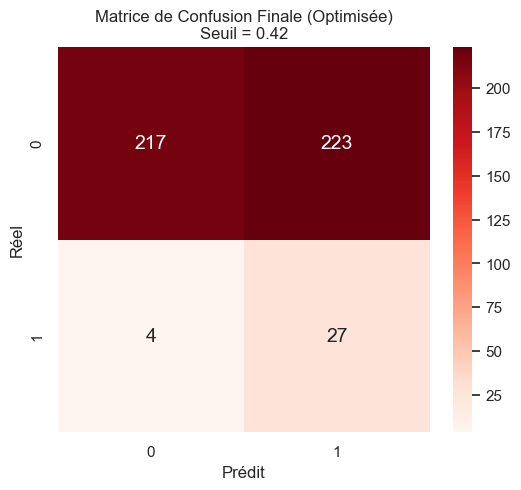

              precision    recall  f1-score   support

           0       0.98      0.49      0.66       440
           1       0.11      0.87      0.19        31

    accuracy                           0.52       471
   macro avg       0.54      0.68      0.42       471
weighted avg       0.92      0.52      0.63       471



In [16]:
# On reprend le Neural Network déjà entraîné
best_model = models['AdaBoost']
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# On cherche le seuil qui garantit 85% de Recall (Sécurité)
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
best_thresh = thresholds[idx]

print(f"--- OPTIMISATION DU SEUIL ---")
print(f"Seuil optimal trouvé : {best_thresh:.4f}")
print(f"Ce seuil garantit de détecter {recall[idx]:.0%} des défauts.")

# Application du seuil
y_pred_opt = (y_prob >= best_thresh).astype(int)

# Matrice Finale
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Reds', annot_kws={"size": 14})
plt.title(f"Matrice de Confusion Finale (Optimisée)\nSeuil = {best_thresh:.2f}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_opt))

--- OPTIMISATION DU SEUIL ---
Seuil optimal trouvé : 0.1800
Ce seuil garantit de détecter 87% des défauts.


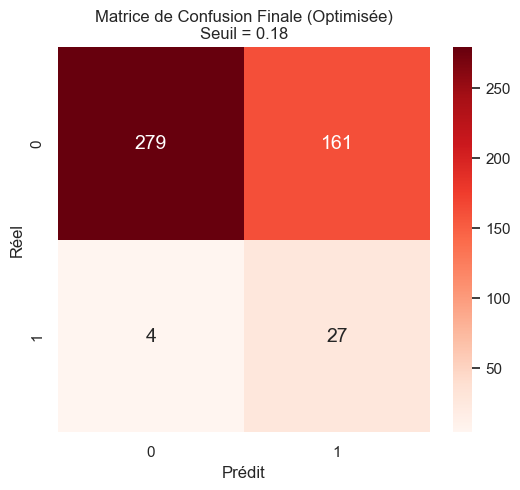

              precision    recall  f1-score   support

           0       0.99      0.63      0.77       440
           1       0.14      0.87      0.25        31

    accuracy                           0.65       471
   macro avg       0.56      0.75      0.51       471
weighted avg       0.93      0.65      0.74       471



In [17]:
# On reprend le Neural Network déjà entraîné
best_model = models['Random Forest']
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# On cherche le seuil qui garantit 85% de Recall (Sécurité)
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
best_thresh = thresholds[idx]

print(f"--- OPTIMISATION DU SEUIL ---")
print(f"Seuil optimal trouvé : {best_thresh:.4f}")
print(f"Ce seuil garantit de détecter {recall[idx]:.0%} des défauts.")

# Application du seuil
y_pred_opt = (y_prob >= best_thresh).astype(int)

# Matrice Finale
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Reds', annot_kws={"size": 14})
plt.title(f"Matrice de Confusion Finale (Optimisée)\nSeuil = {best_thresh:.2f}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_opt))

--- OPTIMISATION DU SEUIL ---
Seuil optimal trouvé : 0.0000
Ce seuil garantit de détecter 100% des défauts.


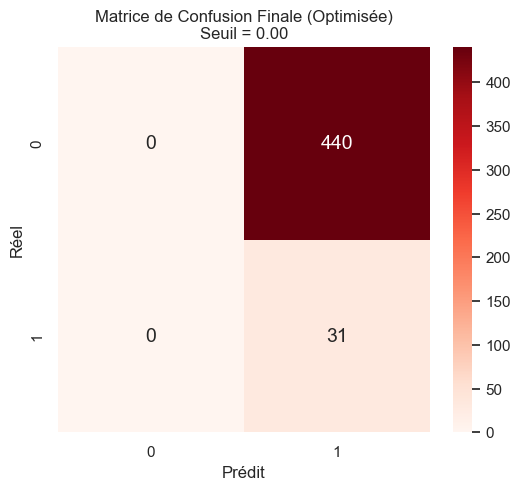

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       440
           1       0.07      1.00      0.12        31

    accuracy                           0.07       471
   macro avg       0.03      0.50      0.06       471
weighted avg       0.00      0.07      0.01       471



c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [18]:
# On reprend le Neural Network déjà entraîné
best_model = models['Decision Tree']
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# On cherche le seuil qui garantit 85% de Recall (Sécurité)
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
best_thresh = thresholds[idx]

print(f"--- OPTIMISATION DU SEUIL ---")
print(f"Seuil optimal trouvé : {best_thresh:.4f}")
print(f"Ce seuil garantit de détecter {recall[idx]:.0%} des défauts.")

# Application du seuil
y_pred_opt = (y_prob >= best_thresh).astype(int)

# Matrice Finale
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Reds', annot_kws={"size": 14})
plt.title(f"Matrice de Confusion Finale (Optimisée)\nSeuil = {best_thresh:.2f}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_opt))